In [75]:
# ELO data only

In [76]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [77]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [78]:
warnings.filterwarnings('ignore')

In [79]:
df = pd.read_csv('data/club-rankings-ext/Matches.csv')

In [80]:
df = df[df['MatchDate'] >= '2016-01-01']

In [81]:
df = df[['Division', 'MatchDate', 'HomeTeam', 'AwayTeam', 'HomeElo', 'AwayElo', 'Form5Home', 'Form5Away', 'FTResult', 'OddHome', 'OddDraw', 'OddAway']]

In [82]:
df.dropna(inplace=True)
df.describe()

,HomeElo,AwayElo,Form5Home,Form5Away,OddHome,OddDraw,OddAway
count,54155.000000,54155.000000,54155.000000,54155.000000,54155.000000,54155.000000,54155.000000
mean,1526.504121,1526.517300,6.761592,6.971582,2.649281,3.815972,4.198196
std,158.291750,158.235507,3.310988,3.309282,1.701870,1.125895,3.225948
min,1115.500000,1115.500000,0.000000,0.000000,0.000000,1.500000,1.060000
25%,1414.910000,1415.090000,4.000000,4.000000,1.770000,3.250000,2.500000
50%,1501.910000,1501.840000,7.000000,7.000000,2.220000,3.500000,3.310000
75%,1626.010000,1625.650000,9.000000,9.000000,2.870000,3.910000,4.620000
max,2093.830000,2096.970000,15.000000,15.000000,34.140000,21.000000,41.220000


In [83]:
df.shape

(54155, 12)

In [84]:
df = df[(df['OddHome'] > 1) & (df['OddDraw'] > 1) & (df['OddAway'] > 1)]
df.dropna(inplace=True)
df.shape

(54154, 12)

In [85]:
df['FTResult'].value_counts() / df.shape[0]

FTResult
H    0.439284
A    0.298168
D    0.262548
Name: count, dtype: float64

In [86]:
original_df = df.copy()

In [87]:
df.groupby('Division').size()

Division
AUT     496
B1     2359
D1     2907
D2     2872
DEN    1111
E0     3608
E1     5228
E2       59
F1     3340
F2     3320
FIN      26
G1     1007
I1     3630
I2     3727
N1     2833
NOR    1377
P1     2863
POL     309
ROM      93
RUS     161
SC0    2027
SC1      12
SP1    3631
SP2    4083
SWE     522
T1     2553
dtype: int64

In [88]:
# pdf = df[df['Division'].isin(['AUT', 'B1', 'D2', 'DEN', 'F2', 'G1', 'I2', 'NOR', 'POL', 'SP2', 'SWE'])].copy()
# pdf = df[df['Division'].isin(['D1', 'E1', 'F1', 'I1', 'SC0', 'SP1'])].copy()
# pdf = df[df['Division'].isin(['NOR', 'POL', 'SWE'])].copy()
pdf = df.copy()

pdf.shape

(54154, 12)

In [89]:
def calculate_probabilities(row, HFA=75, NU=1.65):
    home_elo = row['HomeElo'] # + row['Form5Home'] * 5
    away_elo = row['AwayElo'] # + row['Form5Away'] * 5
    HFA = home_elo * 0.045  # try this
    elo_difference = home_elo - away_elo + HFA

    p_win_base = 1 / (1 + math.pow(10, -elo_difference / 400))
    denom = 1 + NU * p_win_base * (1 - p_win_base)
    pH = p_win_base / denom
    pA = (1 - p_win_base) / denom
    pD = 1 - pH - pA

    return [pH, pD, pA]

In [90]:
pdf[['ProbHome', 'ProbDraw', 'ProbAway']] = pdf.apply(calculate_probabilities, axis=1, result_type='expand')

In [91]:
pdf['Hold'] = 1 / pdf['OddHome'] + 1 / pdf['OddDraw'] + 1 / pdf['OddAway'] - 1

In [92]:
pdf = pdf[pdf['Hold'] <= 0.08]
pdf.shape

(53874, 16)

In [93]:
pdf['ImpliedProbHome'] = 1 / pdf['OddHome'] / (1 + pdf['Hold'])
pdf['ImpliedProbDraw'] = 1 / pdf['OddDraw'] / (1 + pdf['Hold'])
pdf['ImpliedProbAway'] = 1 / pdf['OddAway'] / (1 + pdf['Hold'])

In [94]:
pdf['EV_Home'] = pdf['ProbHome'] * pdf['OddHome']
pdf['EV_Draw'] = pdf['ProbDraw'] * pdf['OddDraw']
pdf['EV_Away'] = pdf['ProbAway'] * pdf['OddAway']

In [95]:
for col in ['ProbHome', 'ProbDraw', 'ProbAway', 'Hold', 'EV_Home', 'EV_Draw', 'EV_Away']:
    pdf[col] = pdf[col].round(5)

In [96]:
def place_bet(row):
    best_prob = max(row['EV_Home'], row['EV_Draw'], row['EV_Away'])
    if row['EV_Home'] == best_prob:
        return 'H'
    elif row['EV_Away'] == best_prob:
        return 'A'
    elif row['EV_Draw'] == best_prob:
        return 'D'

pdf['BetPlaced'] = pdf.apply(place_bet, axis=1)

In [97]:
pdf['BetPlaced'].value_counts()

BetPlaced
A    24964
H    23601
D     5309
Name: count, dtype: int64

In [98]:
pdf.head()

,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,Form5Home,Form5Away,FTResult,OddHome,OddDraw,OddAway,ProbHome,ProbDraw,ProbAway,Hold,ImpliedProbHome,ImpliedProbDraw,ImpliedProbAway,EV_Home,EV_Draw,EV_Away,BetPlaced
119889,E1,2016-01-01,Brighton,Wolves,1493.85,1479.77,3.0,7.0,A,2.20,3.40,3.60,0.44216,0.28094,0.27690,0.02644,0.442836,0.286541,0.270622,0.97275,0.95521,0.99683,A
119890,E1,2016-01-01,QPR,Hull,1491.78,1569.95,4.0,9.0,A,3.20,3.25,2.50,0.34284,0.29183,0.36533,0.02019,0.306315,0.301602,0.392083,1.09709,0.94844,0.91334,H
119921,SC0,2016-01-02,Celtic,Partick,1518.97,1258.57,8.0,13.0,H,1.22,6.50,11.00,0.73164,0.15810,0.11026,0.06443,0.770059,0.144534,0.085407,0.89260,1.02766,1.21285,A
119922,SC0,2016-01-02,Dundee,Dundee United,1225.46,1192.86,4.0,2.0,H,2.20,3.40,3.20,0.44956,0.27916,0.27128,0.06116,0.428346,0.277165,0.294488,0.98903,0.94914,0.86810,H
119924,SC0,2016-01-02,Kilmarnock,Hearts,1170.04,1282.56,4.0,6.0,D,4.50,3.80,1.73,0.29610,0.28596,0.41794,0.06341,0.208970,0.247465,0.543565,1.33245,1.08666,0.72303,H


In [99]:
pdf.describe()

,HomeElo,AwayElo,Form5Home,Form5Away,OddHome,OddDraw,OddAway,ProbHome,ProbDraw,ProbAway,Hold,ImpliedProbHome,ImpliedProbDraw,ImpliedProbAway,EV_Home,EV_Draw,EV_Away
count,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000,53874.000000
mean,1527.046010,1527.034184,6.762112,6.973271,2.648903,3.817252,4.197108,0.437812,0.257964,0.304224,0.056936,0.435388,0.260565,0.304047,0.985007,0.944010,1.001963
std,158.332335,158.298620,3.311691,3.310206,1.701277,1.126593,3.226803,0.149377,0.044260,0.127999,0.011651,0.161045,0.046692,0.146201,0.202545,0.118656,0.241206
min,1115.500000,1115.500000,0.000000,0.000000,1.020000,2.090000,1.060000,0.043890,0.044470,0.027760,0.016730,0.027646,0.045442,0.022968,0.280630,0.325490,0.215560
25%,1415.272500,1415.430000,4.000000,4.000000,1.780000,3.250000,2.500000,0.339773,0.245752,0.220913,0.049360,0.329946,0.242752,0.204624,0.870680,0.875260,0.850510
50%,1502.640000,1502.380000,7.000000,7.000000,2.220000,3.500000,3.310000,0.425125,0.276160,0.290260,0.060380,0.425856,0.271898,0.284792,0.955525,0.936170,0.961525
75%,1626.770000,1626.310000,9.000000,9.000000,2.870000,3.910000,4.620000,0.522848,0.288380,0.368530,0.065680,0.533333,0.291908,0.377672,1.057975,1.001898,1.102477
max,2093.830000,2096.970000,15.000000,15.000000,34.140000,21.000000,41.220000,0.927770,0.292040,0.887100,0.079980,0.926491,0.455636,0.888864,11.897390,2.800140,5.558820


In [100]:
def strategy_flat_elo(row, min_cutoff=1, max_cutoff=3):
    bet_size = 1
    result = None
    
    if pd.isna(row['BetPlaced']):
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) < min_cutoff:
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) > max_cutoff:
        return None, None

    if row['BetPlaced'] == row['FTResult']:
        if row['BetPlaced'] == 'H':
            result = bet_size * (row['OddHome'] - 1)
        elif row['BetPlaced'] == 'D':
            result = bet_size * (row['OddDraw'] - 1)
        elif row['BetPlaced'] == 'A':
            result = bet_size * (row['OddAway'] - 1)
    else:
        result = -bet_size

    return result, bet_size

In [101]:
def strategy_dynamic_elo(row, min_cutoff=1, max_cutoff=3):
    bet_size = 1
    result = None
    
    if pd.isna(row['BetPlaced']):
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) < min_cutoff:
        return None, None
    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) > max_cutoff:
        return None, None

    if max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) == row['EV_Home']:
        bet_size = 1 / row['OddHome']
    elif max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) == row['EV_Draw']:
        bet_size = 1 / row['OddDraw']
    elif max(row['EV_Home'], row['EV_Draw'], row['EV_Away']) == row['EV_Away']:
        bet_size = 1 / row['OddAway']

    if row['BetPlaced'] == row['FTResult']:
        if row['BetPlaced'] == 'H':
            result = bet_size * (row['OddHome'] - 1)
        elif row['BetPlaced'] == 'D':
            result = bet_size * (row['OddDraw'] - 1)
        elif row['BetPlaced'] == 'A':
            result = bet_size * (row['OddAway'] - 1)
    else:
        result = -bet_size

    return result, bet_size

In [102]:
def strategy_flat_home_v2(row):
    bet_size = 1
    result = None
    
    threshold = 1

    if row['OddHome'] >= threshold:
        if row['FTResult'] == 'H':
            result = bet_size * (row['OddHome'] - 1)
        else:
            result = -bet_size

    if result is not None:
        return result, bet_size
    else:
        return None, None

Threshold: 0.5-1.0 | Number of bets: 8759 | Returns: -480.15 | ROI: -5.48%
Threshold: 1.0-1.5 | Number of bets: 42036 | Returns: -3787.96 | ROI: -9.01%
Threshold: 1.5-2.0 | Number of bets: 2593 | Returns: -293.72 | ROI: -11.33%
Threshold: 2.0-2.5 | Number of bets: 376 | Returns: -88.31 | ROI: -23.49%
Threshold: 2.5-3.0 | Number of bets: 74 | Returns: -22.62 | ROI: -30.57%


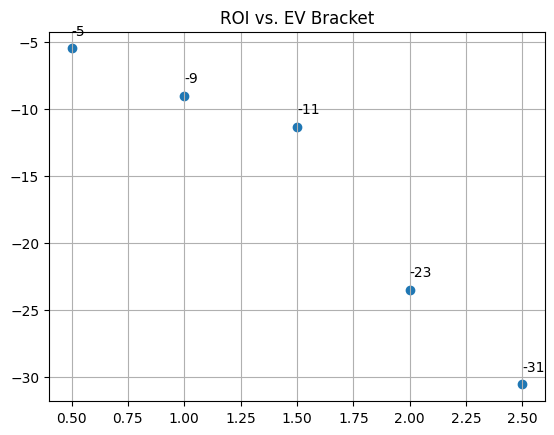

In [103]:
strategy = strategy_flat_elo

results = []

for threshold in [[a, a + 0.5] for a in np.arange(0.5, 3, 0.5)]:
    threshold = [round(t, 2) for t in threshold]
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_thr{threshold[0]}-{threshold[1]}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf[strategy_name_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf[strategy_betsize_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf[strategy_betsize_thresh].count()
    net_profit = round(pdf[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf[strategy_name_thresh].sum() / pdf[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    print(f'Threshold: {threshold[0]}-{threshold[1]} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')

    results.append((threshold[0], net_profit, roi))

offset = 1

plt.figure()
plt.grid(True)
plt.scatter([r[0] for r in results], [r[2] for r in results])

for r in results:
    plt.text(r[0], r[2] + offset, f'{int(round(r[2]))}')

plt.title('ROI vs. EV Bracket')
plt.show()

Threshold: 0.5-1.0 | Number of bets: 8759 | Returns: -165.93 | ROI: -4.76%
Threshold: 1.0-1.5 | Number of bets: 42036 | Returns: -961.86 | ROI: -7.32%
Threshold: 1.5-2.0 | Number of bets: 2593 | Returns: -33.94 | ROI: -9.13%
Threshold: 2.0-2.5 | Number of bets: 376 | Returns: -6.68 | ROI: -17.73%
Threshold: 2.5-3.0 | Number of bets: 74 | Returns: -1.7 | ROI: -25.34%


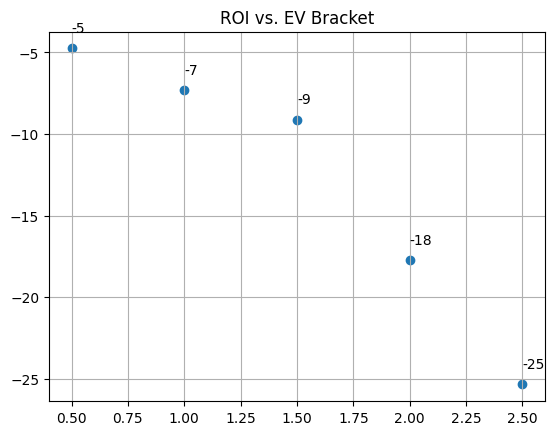

In [104]:
strategy = strategy_dynamic_elo

results = []

for threshold in [[a, a + 0.5] for a in np.arange(0.5, 3, 0.5)]:
    threshold = [round(t, 2) for t in threshold]
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_thr{threshold[0]}-{threshold[1]}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf[strategy_name_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf[strategy_betsize_thresh] = pdf.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf[strategy_betsize_thresh].count()
    net_profit = round(pdf[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf[strategy_name_thresh].sum() / pdf[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    print(f'Threshold: {threshold[0]}-{threshold[1]} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')
    results.append((threshold[0], net_profit, roi))

offset = 1

plt.figure()
plt.grid(True)
plt.scatter([r[0] for r in results], [r[2] for r in results])

for r in results:
    plt.text(r[0], r[2] + offset, f'{int(round(r[2]))}')

plt.title('ROI vs. EV Bracket')
plt.show()

Threshold: 0.5-1.0 | Number of bets: 7019 | Returns: -168.11 | ROI: -5.61%
Threshold: 1.0-1.5 | Number of bets: 38467 | Returns: -958.31 | ROI: -7.86%
Threshold: 1.5-2.0 | Number of bets: 2593 | Returns: -33.94 | ROI: -9.13%
Threshold: 2.0-2.5 | Number of bets: 376 | Returns: -6.68 | ROI: -17.73%
Threshold: 2.5-3.0 | Number of bets: 74 | Returns: -1.7 | ROI: -25.34%


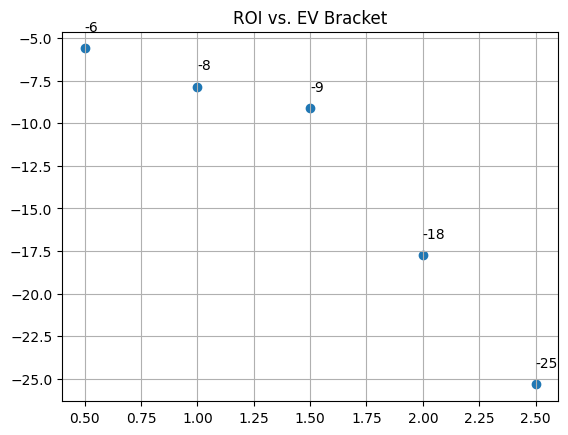

In [105]:
strategy = strategy_dynamic_elo

results = []

pdf_filtered = pdf[pdf['BetPlaced'] != 'D'].copy()

for threshold in [[a, a + 0.5] for a in np.arange(0.5, 3, 0.5)]:
    threshold = [round(t, 2) for t in threshold]
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_thr{threshold[0]}-{threshold[1]}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf_filtered[strategy_name_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf_filtered[strategy_betsize_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf_filtered[strategy_betsize_thresh].count()
    net_profit = round(pdf_filtered[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf_filtered[strategy_name_thresh].sum() / pdf_filtered[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    print(f'Threshold: {threshold[0]}-{threshold[1]} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')
    results.append((threshold[0], net_profit, roi))

offset = 1

plt.figure()
plt.grid(True)
plt.scatter([r[0] for r in results], [r[2] for r in results])

for r in results:
    plt.text(r[0], r[2] + offset, f'{int(round(r[2]))}')

plt.title('ROI vs. EV Bracket')
plt.show()

BetPlaced
H    24964
A    23601
Name: count, dtype: int64
Threshold: 0.5-1.0 | Number of bets: 7019 | Returns: -381.7 | ROI: -12.73%
Threshold: 1.0-1.5 | Number of bets: 38467 | Returns: -895.66 | ROI: -7.34%
Threshold: 1.5-2.0 | Number of bets: 2593 | Returns: -13.2 | ROI: -3.55%
Threshold: 2.0-2.5 | Number of bets: 376 | Returns: 1.38 | ROI: 3.67%
Threshold: 2.5-3.0 | Number of bets: 74 | Returns: -0.39 | ROI: -5.75%


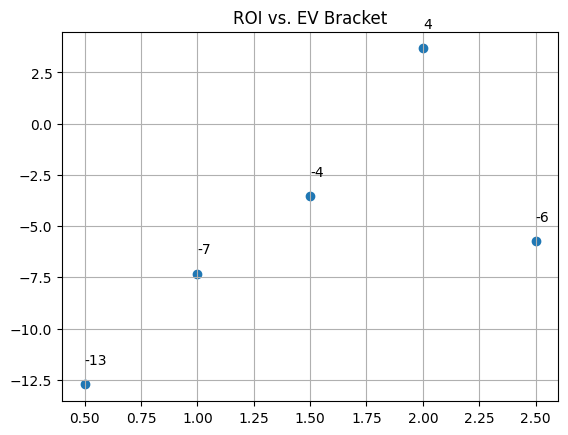

In [111]:
# UNO REVERSE

strategy = strategy_dynamic_elo

results = []

pdf_filtered = pdf[pdf['BetPlaced'] != 'D'].copy()
pdf_filtered['BetPlaced'] = pdf_filtered['BetPlaced'].replace({'A': 'H', 'H': 'A'})
print(pdf_filtered['BetPlaced'].value_counts())

for threshold in [[a, a + 0.5] for a in np.arange(0.5, 3, 0.5)]:
    threshold = [round(t, 2) for t in threshold]
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_thr{threshold[0]}-{threshold[1]}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf_filtered[strategy_name_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf_filtered[strategy_betsize_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf_filtered[strategy_betsize_thresh].count()
    net_profit = round(pdf_filtered[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf_filtered[strategy_name_thresh].sum() / pdf_filtered[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    print(f'Threshold: {threshold[0]}-{threshold[1]} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')
    results.append((threshold[0], net_profit, roi))

offset = 1

plt.figure()
plt.grid(True)
plt.scatter([r[0] for r in results], [r[2] for r in results])

for r in results:
    plt.text(r[0], r[2] + offset, f'{int(round(r[2]))}')

plt.title('ROI vs. EV Bracket')
plt.show()

In [106]:
strategy = strategy_dynamic_elo

results = []

threshold = [1.25, 3]

divisions = pdf['Division'].unique()
for division in divisions:
    # pdf_filtered = pdf[(pdf['BetPlaced'] != 'D') & (pdf['Division'] == division)].copy()
    pdf_filtered = pdf[(pdf['Division'] == division)].copy()
    if pdf_filtered.shape[0] < 100:
        continue
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_div_{division}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf_filtered[strategy_name_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf_filtered[strategy_betsize_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf_filtered[strategy_betsize_thresh].count()
    net_profit = round(pdf_filtered[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf_filtered[strategy_name_thresh].sum() / pdf_filtered[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    # print(f'Division: {division} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')
    results.append((division, number_of_bets, net_profit, roi, ))

results_df = pd.DataFrame(results, columns=['Division', 'NumberOfBets', 'NetProfit', 'ROI'])
results_df.sort_values(by='NumberOfBets', ascending=False, inplace=True)
results_df.head(30)

,Division,NumberOfBets,NetProfit,ROI
2,E0,1087,-11.57,-6.59
0,E1,922,-16.96,-8.27
3,SP1,765,-11.78,-8.68
9,I1,695,-12.91,-10.01
14,F1,668,-5.54,-4.64
5,SP2,628,-26.23,-19.40
20,D1,595,-7.68,-7.78
13,F2,544,-6.20,-4.91
17,I2,533,-5.79,-4.95
16,N1,467,-10.49,-16.02


In [112]:
strategy = strategy_dynamic_elo

results = []

threshold = [1.25, 3]

divisions = pdf['Division'].unique()
for division in divisions:
    # pdf_filtered = pdf[(pdf['BetPlaced'] != 'D') & (pdf['Division'] == division)].copy()
    pdf_filtered = pdf[(pdf['Division'] == division)].copy()
    pdf_filtered['BetPlaced'] = pdf_filtered['BetPlaced'].replace({'A': 'H', 'H': 'A'})
    if pdf_filtered.shape[0] < 100:
        continue
    strategy_name = strategy.__name__
    strategy_name_thresh = f'{strategy_name}_div_{division}'
    strategy_betsize_thresh = f'{strategy_name_thresh}_bet_size'
    pdf_filtered[strategy_name_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[0], axis=1)
    pdf_filtered[strategy_betsize_thresh] = pdf_filtered.apply(lambda row: strategy(row, min_cutoff=threshold[0], max_cutoff=threshold[1])[1], axis=1)
    
    number_of_bets = pdf_filtered[strategy_betsize_thresh].count()
    net_profit = round(pdf_filtered[strategy_name_thresh].sum(), 2)
    try:
        roi = round(pdf_filtered[strategy_name_thresh].sum() / pdf_filtered[strategy_betsize_thresh].sum() * 100, 2)
    except ZeroDivisionError:
        roi = 0
    # print(f'Division: {division} | Number of bets: {number_of_bets} | Returns: {net_profit} | ROI: {roi}%')
    results.append((division, number_of_bets, net_profit, roi, ))

results_df = pd.DataFrame(results, columns=['Division', 'NumberOfBets', 'NetProfit', 'ROI'])
results_df.sort_values(by='NumberOfBets', ascending=False, inplace=True)
results_df.head(30)

,Division,NumberOfBets,NetProfit,ROI
2,E0,1087,-3.18,-1.81
0,E1,922,-6.29,-3.07
3,SP1,765,-10.65,-7.85
9,I1,695,-1.12,-0.87
14,F1,668,3.80,3.18
5,SP2,628,-1.74,-1.29
20,D1,595,4.14,4.19
13,F2,544,-7.75,-6.14
17,I2,533,-15.56,-13.32
16,N1,467,1.35,2.06


In [107]:
# plt.figure(figsize=(10, 6))
# plt.grid(True)

# pdf_filtered = pdf[(pdf['FTResult'] == 'H') & (pdf['BetPlaced'] == 'H')].copy().reset_index()
# plt.scatter([pdf_filtered['ImpliedProbHome'] for p in pdf_filtered.iterrows()], [pdf_filtered['ProbHome'] for p in pdf_filtered.iterrows()], c='blue', s=2)

# pdf_filtered = pdf[(pdf['FTResult'] == 'D') & (pdf['BetPlaced'] == 'H')].copy().reset_index()
# plt.scatter([pdf_filtered['ImpliedProbHome'] for p in pdf_filtered.iterrows()], [pdf_filtered['ProbHome'] for p in pdf_filtered.iterrows()], c='red', s=2)

# pdf_filtered = pdf[(pdf['FTResult'] == 'A') & (pdf['BetPlaced'] == 'H')].copy().reset_index()
# plt.scatter([pdf_filtered['ImpliedProbHome'] for p in pdf_filtered.iterrows()], [pdf_filtered['ProbHome'] for p in pdf_filtered.iterrows()], c='green', s=2)

# plt.xlabel('Implied Probability Home Win')
# plt.ylabel('Model-predicted Probability Home Win')
# plt.show()

In [108]:
pdf.to_csv('data/tmp_betting_backtest_results_elo.csv', index=False)